In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("Libraries imported successfully")

C:\Users\User\AppData\Local\Temp\ipykernel_26592\3088693304.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries imported successfully


In [5]:
#load csv file

df = pd.read_csv('data/diabetic_data.csv')

print("DATASET OVERVIEW")
print("="*20)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 3 rows:")
print(df.head(3))

DATASET OVERVIEW
Shape: 101766 rows, 50 columns

First 3 rows:
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No   
1                 3  ...          No      Up                   No   
2                 2  ...          No      No                   No   

   glipizide-metformin  glimepiride-pioglitazone  metformin-rosiglitazone  \
0    

In [7]:
#quick data exploration
print("COLUMN INFORMATION")
print("="*20)
print(df.info())

print("\n" + "_"*70)
print("BASIC STATISTICS")
print("="*20)
print(df.describe())

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-nul

In [8]:
#check readmission categories
print("READMISSION CATEGORIES")
print("="*20)
print(df['readmitted'].value_counts())
print("\nPercentage distribution : ")
print(df['readmitted'].value_counts(normalize=True) * 100)



READMISSION CATEGORIES
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Percentage distribution : 
readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


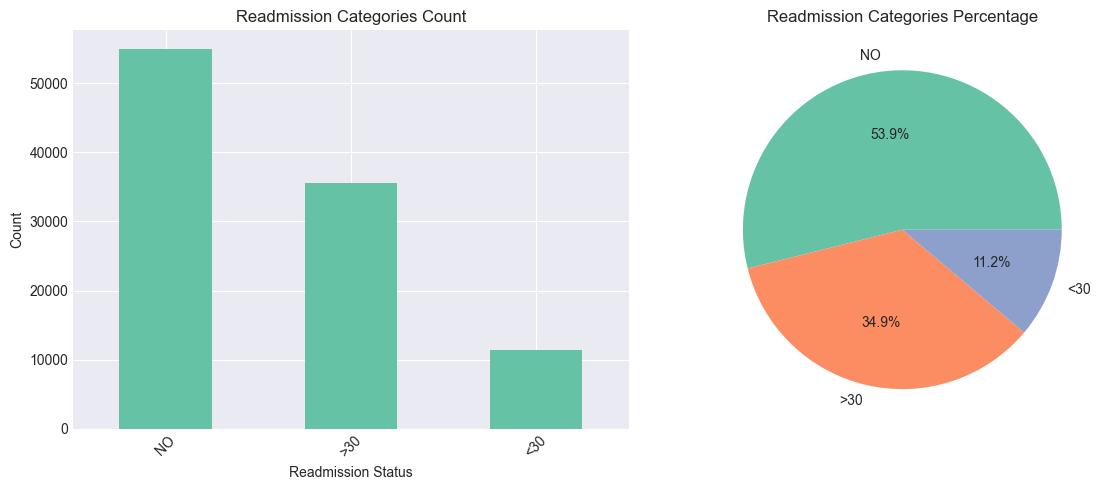

In [10]:
#visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#bar plot
df['readmitted'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Readmission Categories Count')
axes[0].set_xlabel('Readmission Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

#pie chart
df['readmitted'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Readmission Categories Percentage')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/readmission_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [15]:
#create binary target
## 1 = readmitted within 30 days, 0 = otherwise

df['target'] =  (df['readmitted'] == '<30').astype(int)

print("BINARY TARGET CREATED")
print("="*30)
print(f"Target = 1 (Readmitted within 30 days): {df['target'].sum():,} patients")
print(f"Target = 0 (No or late readmission): {(df['target'] == 0).sum():,} patients")
print(f"\nReadmission rate within 30 days: {df['target'].mean()*100:.2f}%")

#check if imbalanced
print("="*30)
print("CLASS IMBALANCE ANALYSIS")
print("="*30)

n_positive = df['target'].sum()
n_negative = (df['target'] == 0).sum()
total = len(df)
positive_pct = (n_positive / total) * 100
imbalance_ratio = n_negative / n_positive

print(f"Positive class (readmitted): {n_positive:,} ({positive_pct:.2f}%)")
print(f"Negative class (not readmitted): {n_negative:,} ({100-positive_pct:.2f}%)")
print(f"Imbalance Ratio: {imbalance_ratio:.1f}:1 (negative:positive)")

###
if imbalance_ratio >= 3:
    print("\n   DATASET IS IMBALANCED !!!   ")
    print( "_"*30)
    print(f"   Positive class is only {positive_pct:.1f}% of data")
    print("   ---> Model will be USELESS without imbalance handling")
    print("   ---> Will use Class Weights technique")

    #calculate classweights
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np

    classes = np.array([0, 1])
    weights = compute_class_weight('balanced', classes=classes, y=df['target'])
    class_weight_dict = {0: weights[0], 1:weights[1]}

    print(f"\n SOLUTION: Class Weights calculated")
    print(f"   Class 0 (not readmitted) weight: {weights[0]:.3f}")
    print(f"   Class 1 (readmitted) weight: {weights[1]:.3f}")
    print(f"  ---> Model will pay {weights[1]/weights[0]:.1f}x more attention to readmitted patients")

    use_balancing = True
elif imbalance_ratio >= 1.5:
    print("   ---> Consider using class weights for better results")
    
    ####
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np
    
    classes = np.array([0, 1])
    weights = compute_class_weight('balanced', classes=classes, y=df['target'])
    class_weight_dict = {0: weights[0], 1: weights[1]}
    use_balancing = True
    
else:
    print("\n DATASET IS BALANCED")
    print("   ---> No special handling needed")
    class_weight_dict = None
    use_balancing = False

#store for later use
df.attrs['class_weights'] = class_weight_dict

BINARY TARGET CREATED
Target = 1 (Readmitted within 30 days): 11,357 patients
Target = 0 (No or late readmission): 90,409 patients

Readmission rate within 30 days: 11.16%
CLASS IMBALANCE ANALYSIS
Positive class (readmitted): 11,357 (11.16%)
Negative class (not readmitted): 90,409 (88.84%)
Imbalance Ratio: 8.0:1 (negative:positive)

   DATASET IS IMBALANCED !!!   
______________________________
   Positive class is only 11.2% of data
   ---> Model will be USELESS without imbalance handling
   ---> Will use Class Weights technique

 SOLUTION: Class Weights calculated
   Class 0 (not readmitted) weight: 0.563
   Class 1 (readmitted) weight: 4.480
  ---> Model will pay 8.0x more attention to readmitted patients


In [17]:
#handle missing values
print("HANDLING MISSING VALUES")
print("="*30)

#count '?'
question_counts = {}
for col in df.columns:
    q_count = (df[col] == '?').sum()
    if q_count > 0:
        question_counts[col] = q_count
        print(f"  {col} : {q_count:,} '?' values")

##replace '?' with NaN
df = df.replace('?', np.nan)

print(f"\n Replaced '?' with NaN in {len(question_counts)} columns")

HANDLING MISSING VALUES
  race : 2,273 '?' values
  weight : 98,569 '?' values
  payer_code : 40,256 '?' values
  medical_specialty : 49,949 '?' values
  diag_1 : 21 '?' values
  diag_2 : 358 '?' values
  diag_3 : 1,423 '?' values

 Replaced '?' with NaN in 7 columns


In [18]:
#drop useless columns
print("DROPPING USELESS COLUMNS")
print("="*30)

#drop ---- >  unique identifiers or too many missing
cols_to_drop = ['encounter_id', 'patient_nbr', 'weight']

##check if >50% missing
if 'payer_code' in df.columns:
    missing_pct = (df['payer_code'].isnull().sum() / len(df)) * 100

    if missing_pct > 50:
        cols_to_drop.append('payer_code')
        print(f"  payer_code : {missing_pct:.1f}%missing ---> dropping")

if 'medical_speciality' in df.columns:
    missing_pct = df['medical_specialty'].isnull().sum() / len(df) * 100
    
    if missing_pct > 50:
        cols_to_drop.append('medical_specialty')
        print(f"  medical_specialty: {missing_pct:.1f}% missing → dropping")

##drop columns
cols_to_drop_existing = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop_existing)

print(f"\n Dropped: {cols_to_drop_existing}")
print(f" New shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

DROPPING USELESS COLUMNS

 Dropped: ['encounter_id', 'patient_nbr', 'weight']
 New shape: 101,766 rows, 48 columns


In [20]:
#fill remaining missing values
print("FILLING MISSING VALUES")
print("="*30)

## for categorical columns - fill with 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    if col != 'readmitted' and df[col].isnull().sum() > 0:
        missing_count = df[col].isnull().sum()
        df[col] = df[col].fillna('Unknown')
        print(f" {col} : Filled {missing_count:,} with 'Unknown'")

#for numerical columns ---- fill with median
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numerical_cols:
    if col != 'target' and df[col].isnull().sum() > 0:
        missing_count= df[col].isnull().sum()
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"  {col}: Filled {missing_count:,} with median ({median_val})")

print(f"\n All missing values filled")
print(f" Remaining missing: {df.isnull().sum().sum()}")

FILLING MISSING VALUES

 All missing values filled
 Remaining missing: 0


In [22]:
###feature engineering --------- create new features
print("FEATURE ENGINEERING")
print("="*30)

#total visists ---> outpatient + emergency + inpatient
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
print("Created 'total_visits'")

# medications per day----- if tome_in_hospital > 0
df['meds_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 0.1)
print("Created 'meds_per_day'")

# procedures per day
df['procedures_per_day'] = df['num_procedures'] / (df['time_in_hospital'] + 0.1)
print("Created 'procedures_per_day'")

# lab procedures per day
df['lab_per_day'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 0.1)
print("Created 'lab_per_day'")

#has emergency visit ---- binary
df['had_emergency'] = (df['number_emergency'] > 0).astype(int)
print("Created 'had_emergency'")

#has inpatient visit ------binary
df['had_inpatient'] = (df['number_inpatient'] > 0).astype(int)
print("Created 'had_inpatient'")

print(f"\nNew shape after feature engineering: {df.shape[1]} columns")

FEATURE ENGINEERING
Created 'total_visits'
Created 'meds_per_day'
Created 'procedures_per_day'
Created 'lab_per_day'
Created 'had_emergency'
Created 'had_inpatient'

New shape after feature engineering: 54 columns


In [25]:
####encode categoriacal variables

print("ENCODING CATEGORICAL VARIABLES")
print("="*50)

#identify categorical columns --- exclude target and readmitted
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['readmitted', 'target']]

print(f"Categorical columns to encode: {len(categorical_cols)}")
print(f"  {categorical_cols}")

#perform one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(f"\nEncoding complete!")
print(f"  Original columns: {df.shape[1]}")
print(f"  Encoded columns: {df_encoded.shape[1]}")
print(f"  Increase: +{df_encoded.shape[1] - df.shape[1]} columns")

ENCODING CATEGORICAL VARIABLES
Categorical columns to encode: 35
  ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

Encoding complete!
  Original columns: 54
  Encoded columns: 2433
  Increase: +2379 columns


In [27]:
#split features and target
print("PREPARING DATA FOR MODEL TRAINING")
print("="*50)

X = df_encoded.drop(columns=['target', 'readmitted'])
y = df_encoded['target']

print(f"Features shape (X) : {X.shape}")
print(f"Target shape (y) : {y.shape}")
print(f"Positive class in y : {y.sum():,}  ({y.mean()*100:.2f}%)")

#verfy class weights are available
if use_balancing:
    print(f"\n Class weights will be used during training:")
    print(f"   Class 0: {class_weight_dict[0]:.3f}")
    print(f"   Class 1: {class_weight_dict[1]:.3f}")

PREPARING DATA FOR MODEL TRAINING
Features shape (X) : (101766, 2431)
Target shape (y) : (101766,)
Positive class in y : 11,357  (11.16%)

 Class weights will be used during training:
   Class 0: 0.563
   Class 1: 4.480


In [28]:
#split into training and testing sets
from sklearn.model_selection import train_test_split

print("TRAIN-TEST SPLIT")
print("="*20)

#split data ----- 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"  --- Positive class: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Testing set: {X_test.shape[0]:,} samples")
print(f"  --- Positive class: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

TRAIN-TEST SPLIT
Training set: 71,236 samples
  --- Positive class: 7,950 (11.16%)
Testing set: 30,530 samples
  --- Positive class: 3,407 (11.16%)


In [30]:
#save cleaned and encoded data
print("SAVING PROCESSED DATA")
print("="*30)

df_encoded.to_csv('data/cleaned_data_encoded.csv', index=False)
print("Saved : data/cleaned_data_encoded.csv")

#save X_train, X_tset,y_train, y_tset
import joblib
joblib.dump(X_train, 'data/X_train.pkl')
joblib.dump(X_test, 'data/X_test.pkl')
joblib.dump(y_train, 'data/y_train.pkl')
joblib.dump(y_test, 'data/y_test.pkl')
print("Saved : X_train, X_test, y_train, y_test as .pkl files")

#save class weights if they exist
if use_balancing:
    joblib.dump(class_weight_dict, 'models/class_weights.pkl')
    print("Saved: class_weights.pkl")

print("\n" + "="*50)
print(" DATA PREPROCESSING COMPLETE!")
print("="*50)
print("\n FINAL SUMMARY:")
print(f"   - Total samples: {len(df_encoded):,}")
print(f"   - Features after encoding: {X.shape[1]}")
print(f"   - Training samples: {X_train.shape[0]:,}")
print(f"   - Testing samples: {X_test.shape[0]:,}")
print(f"   - Class imbalance handled: {'YES (Class Weights)' if use_balancing else 'NO'}")
# print("\n NEXT: Model Training - Random Forest with Class Weights")

SAVING PROCESSED DATA
Saved : data/cleaned_data_encoded.csv
Saved : X_train, X_test, y_train, y_test as .pkl files
Saved: class_weights.pkl

 DATA PREPROCESSING COMPLETE!

 FINAL SUMMARY:
   - Total samples: 101,766
   - Features after encoding: 2431
   - Training samples: 71,236
   - Testing samples: 30,530
   - Class imbalance handled: YES (Class Weights)
